In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn as sk

In [12]:
# load the movies dataset
mnames= ['movie_id','title','genres']
movies = pd.read_table(
    "data/movies.txt",
    sep="::",
    header=None,
    names= mnames,
    engine="python"
)
movies.head()

,movie_id,title,genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy


In [13]:
movies.shape

(3883, 3)

In [14]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3883 entries, 0 to 3882
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   movie_id  3883 non-null   int64 
 1   title     3883 non-null   object
 2   genres    3883 non-null   object
dtypes: int64(1), object(2)
memory usage: 91.1+ KB


In [15]:
# load rating
rnames=['user_id','movie_id','rating','timestamp']
ratings=pd.read_table(
    "data/ratings.txt",
    sep="::",
    header= None,
    names=rnames,
    engine="python"
)
ratings.head()

,user_id,movie_id,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


In [16]:
# load users
unames=['gender','user_id','occupation','zip']
users=pd.read_table(
    "data/users.txt",
    sep="::",
    header= None,
    names=unames,
    engine="python"
)
users.head()

,gender,user_id,occupation,zip
1,F,1,10,48067
2,M,56,16,70072
3,M,25,15,55117
4,M,45,7,02460
5,M,25,20,55455


In [17]:
ratings.shape

(1000209, 4)

In [18]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000209 entries, 0 to 1000208
Data columns (total 4 columns):
 #   Column     Non-Null Count    Dtype
---  ------     --------------    -----
 0   user_id    1000209 non-null  int64
 1   movie_id   1000209 non-null  int64
 2   rating     1000209 non-null  int64
 3   timestamp  1000209 non-null  int64
dtypes: int64(4)
memory usage: 30.5 MB


In [19]:
users.shape

(6040, 4)

In [20]:
display("ratings","users","movies.head()")

'ratings'

'users'

'movies.head()'

In [21]:
display(users, ratings, movies.head())

,gender,user_id,occupation,zip
1,F,1,10,48067
2,M,56,16,70072
3,M,25,15,55117
4,M,45,7,02460
5,M,25,20,55455
...,...,...,...,...
6036,F,25,15,32603
6037,F,45,1,76006
6038,F,56,1,14706
6039,F,45,0,01060


,user_id,movie_id,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291
...,...,...,...,...
1000204,6040,1091,1,956716541
1000205,6040,1094,5,956704887
1000206,6040,562,5,956704746
1000207,6040,1096,4,956715648


,movie_id,title,genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy


In [22]:
# merge rating and user
user_ratings = pd.merge(ratings,users )
user_ratings.head()

,user_id,movie_id,rating,timestamp,gender,occupation,zip
0,1,1193,5,978300760,F,10,48067
1,1,1193,5,978300760,M,10,48073
2,1,1193,5,978300760,F,10,10562
3,1,1193,5,978300760,F,10,01748
4,1,1193,5,978300760,F,10,54467


In [23]:
data = pd.merge(user_ratings,movies)
data.head()

,user_id,movie_id,rating,timestamp,gender,occupation,zip,title,genres
0,1,1193,5,978300760,F,10,48067,One Flew Over the Cuckoo's Nest (1975),Drama
1,1,1193,5,978300760,M,10,48073,One Flew Over the Cuckoo's Nest (1975),Drama
2,1,1193,5,978300760,F,10,10562,One Flew Over the Cuckoo's Nest (1975),Drama
3,1,1193,5,978300760,F,10,01748,One Flew Over the Cuckoo's Nest (1975),Drama
4,1,1193,5,978300760,F,10,54467,One Flew Over the Cuckoo's Nest (1975),Drama


In [24]:
data.shape
data.info

<bound method DataFrame.info of         user_id  movie_id  rating  timestamp gender  occupation    zip  \
0             1      1193       5  978300760      F          10  48067   
1             1      1193       5  978300760      M          10  48073   
2             1      1193       5  978300760      F          10  10562   
3             1      1193       5  978300760      F          10  01748   
4             1      1193       5  978300760      F          10  54467   
...         ...       ...     ...        ...    ...         ...    ...   
972688       56      1095       3  977938904      M          13  12124   
972689       56      1095       3  977938904      M           7  98103   
972690       56      1095       3  977938904      M           1  42503   
972691       56      1095       3  977938904      F           1  01060   
972692       56      1095       3  977938904      F           1  14706   

                                         title genres  
0       One Flew Over t

In [25]:
data.describe()

,user_id,movie_id,rating,timestamp,occupation
count,972693.000000,972693.000000,972693.000000,9.726930e+05,972693.000000
mean,29.435429,1849.902555,3.523770,9.781086e+08,7.865155
std,11.599945,1067.917043,1.215053,8.827104e+04,6.322675
min,1.000000,1.000000,1.000000,9.779386e+08,0.000000
25%,18.000000,1028.000000,3.000000,9.781011e+08,3.000000
50%,25.000000,1876.000000,4.000000,9.781312e+08,6.000000
75%,35.000000,2692.000000,4.000000,9.781538e+08,14.000000
max,56.000000,3948.000000,5.000000,9.788244e+08,20.000000


In [26]:
data['rating'].describe()

count    972693.000000
mean          3.523770
std           1.215053
min           1.000000
25%           3.000000
50%           4.000000
75%           4.000000
max           5.000000
Name: rating, dtype: float64

In [27]:
data['rating'].value_counts().sort_index()

rating
1     83239
2    108351
3    235446
4    307018
5    238639
Name: count, dtype: int64

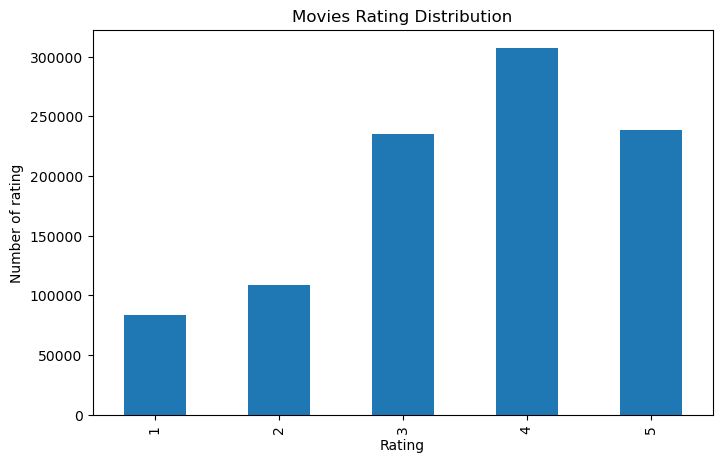

In [28]:
#rating distribution
plt.figure(figsize=(8,5))
data['rating'].value_counts().sort_index().plot(kind='bar')

plt.title('Movies Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Number of rating')
plt.show()

In [29]:
#most rated movies
movie_rating_count = (
    data.groupby('title')['rating']
    .count()
    .sort_values(ascending=False)
)
movie_rating_count.head(10)

title
Chicken Run (2000)                                       4888
Star Wars: Episode VI - Return of the Jedi (1983)        4392
Star Wars: Episode V - The Empire Strikes Back (1980)    4392
Raiders of the Lost Ark (1981)                           4392
Bug's Life, A (1998)                                     4351
Aladdin (1992)                                           4351
Saving Private Ryan (1998)                               3801
Galaxy Quest (1999)                                      3749
Men in Black (1997)                                      3749
Chasing Amy (1997)                                       3749
Name: rating, dtype: int64

In [30]:
# Avgrage movie rating
movie_avg_rating = (
    data.groupby('title')['rating']
    .mean()
    .sort_values(ascending=False)
)
movie_avg_rating.head(10)

title
Lion King, The (1994)                   5.0
How to Make an American Quilt (1995)    5.0
GoldenEye (1995)                        5.0
GoodFellas (1990)                       5.0
Goonies, The (1985)                     5.0
Great Muppet Caper, The (1981)          5.0
Hamlet (1996)                           5.0
Harvey (1950)                           5.0
Heaven Can Wait (1978)                  5.0
High Noon (1952)                        5.0
Name: rating, dtype: float64

In [31]:
# innovation : reliable mvie rating
movie_stats= data.groupby('title')['rating'].agg(
['mean','count']
    )
movie_stats.head()

,mean,count
title,,
'Til There Was You (1997),1.0,550
101 Dalmatians (1961),4.0,1103
101 Dalmatians (1996),1.0,1103
"13th Warrior, The (1999)",4.0,1103
20 Dates (1998),2.0,550


In [32]:
movie_stats.columns = ['avg_rating','rating_count']

In [33]:
popular_movies = movie_stats[
    movie_stats['rating_count'] >= 100
    ].sort_values(
    'avg_rating',
    ascending=False
)
popular_movies.head()

,avg_rating,rating_count
title,,
"Lion King, The (1994)",5.0,1483
How to Make an American Quilt (1995),5.0,550
GoldenEye (1995),5.0,1103
GoodFellas (1990),5.0,380
"Goonies, The (1985)",5.0,1103


In [34]:
movie_stats

,avg_rating,rating_count
title,,
'Til There Was You (1997),1.000000,550
101 Dalmatians (1961),4.000000,1103
101 Dalmatians (1996),1.000000,1103
"13th Warrior, The (1999)",4.000000,1103
20 Dates (1998),2.000000,550
...,...,...
Young Frankenstein (1974),3.684452,1743
Young Guns (1988),4.000000,1103
Young Guns II (1990),3.000000,1103


In [35]:
#hidden gem :innovation
hidden_gem = movie_stats[
    (movie_stats['avg_rating'] >= 4.0) &
    (movie_stats['rating_count'] >= 50) &
    (movie_stats['rating_count'] <= 500)
].sort_values(
    'avg_rating',
    ascending=False
)

hidden_gem.head(10)
#"Here are highly rated movies that aren't among the most heavily rated titles."

,avg_rating,rating_count
title,,
American History X (1998),5.0,380
Rain Man (1988),5.0,222
Waking Ned Devine (1998),5.0,380
Awakenings (1990),5.0,222
Ben-Hur (1959),5.0,222
Three Kings (1999),5.0,380
"Thin Red Line, The (1998)",5.0,380
"Last Days of Disco, The (1998)",5.0,222
"Fugitive, The (1993)",5.0,380


In [36]:
#genre analysis
genres = data['genres'].str.split('|')

In [37]:
genre_count = (
    data['genres']
    .str.split('|')
    .explode()
    .value_counts()
)
genre_count.head()

genres
Comedy       383172
Drama        345434
Action       272336
Romance      222129
Adventure    171851
Name: count, dtype: int64

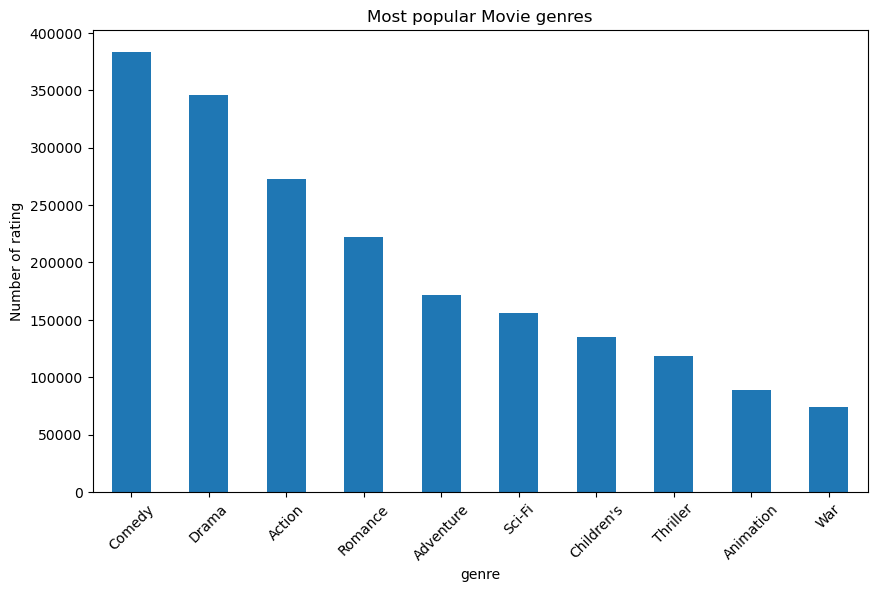

In [38]:
plt.figure(figsize=(10,6))
genre_count.head(10).plot(kind='bar')

plt.title('Most popular Movie genres')
plt.xlabel('genre')
plt.ylabel('Number of rating')

plt.xticks(rotation = 45)
plt.show()

In [39]:
#your original notebook analysis
mean_rating = data.pivot_table(
    values="rating",
    index="title",
    columns ="gender",
    aggfunc="mean"
)
mean_rating.head()


gender,F,M
title,,
'Til There Was You (1997),1.0,1.0
101 Dalmatians (1961),4.0,4.0
101 Dalmatians (1996),1.0,1.0
"13th Warrior, The (1999)",4.0,4.0
20 Dates (1998),2.0,2.0


In [40]:
mean_rating['diff'] = (
    mean_rating['M'] - mean_rating['F']
)

In [50]:
#Recommendation System
# Toy Story
#        ↓
# Animation + Children's + Comedy
#        ↓
# Compare all movies
#        ↓
# Calculate similarity
#        ↓
# Find closest movies
#        ↓
# Top 5 recommendations
# convert genre into number 

from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(
    tokenizer = lambda x: x.split('|'),
    token_pattern=None
)
tfidf_matrix = tfidf.fit_transform(
    movies['genres']
)

In [51]:
# calculate similarity
from sklearn.metrics.pairwise import cosine_similarity
similarity = cosine_similarity(tfidf_matrix)

In [92]:
def recommend_movies(movie_title, n=5):
    # Clean the input movie title
    movie_title = movie_title.strip().lower()
    
    # Find the movie
    matched_movies = movies[
         movies['title'].str.strip().str.lower() == movie_title
         ]
        
      # Check if movie exists
    if matched_movies.empty:
        print("Movie not found.")
        print("Please check the movie title")
        return
        # Get movie index
    movie_index = matched_movies.index[0]
        # Get similarity scores
    similarity_score = list(
       enumerate(similarity[movie_index])
       )
    #sort movies by similarity
    similarity_score =  sorted(
        similarity_score,
        key=lambda x: x[1],
        reverse = True
        )
    # Remove the selected movie
    similar_movies = similarity_score[1:n+1]
  # get movie indexes
    movie_indices = [
        index for index , score in similar_movies
        ]
      # return the recommended movies
    return movies.iloc[movie_indices][
        ['title','genres']
        ]
    

In [93]:
recommend_movies('Toy Story (1995)')

,title,genres
1050,Aladdin and the King of Thieves (1996),Animation|Children's|Comedy
2072,"American Tail, An (1986)",Animation|Children's|Comedy
2073,"American Tail: Fievel Goes West, An (1991)",Animation|Children's|Comedy
2285,"Rugrats Movie, The (1998)",Animation|Children's|Comedy
2286,"Bug's Life, A (1998)",Animation|Children's|Comedy


In [89]:
# mood base recommendation 
mood_genres = {
    'happy':['comedy','Animation'],
    'romantic':['Romance'],
    'scary':['Horror','thriller'],
    'adventure':['Adventure','Action'],
    'emotional':['Drama','Romance'],
    }
    

In [96]:
def recommend_by_mood(mood, n=10):
   # Clean the mood entered by user
    mood = mood.strip().lower()
    # check whether mood os exists
    if mood not in mood_genres:
        print("Mood not available ")
        print("Available mood :",list(mood_genres.key()))
        return
      # Get genres for selected mood
    genres= mood_genres[mood]

    # Create pattern for multiple genres
    pattern = '|'.join(genres)
    # Find movies matching the mood genres
    mood_movies = movies[
    movies['genres']
    .fillna('')
    .str.contains(
    pattern,
    case=False,
    na=False
    )
        ]
    # Return movies
    return mood_movies[
        ['title', 'genres']
    ].head(n)

In [90]:
print("movies:", movies.shape)
print("users:", users.shape)
print("ratings:", ratings.shape)
print("data:", data.shape)

movies: (3883, 3)
users: (6040, 4)
ratings: (1000209, 4)
data: (972693, 9)


In [60]:
print(data.isnull().sum())

user_id       0
movie_id      0
rating        0
timestamp     0
gender        0
occupation    0
zip           0
title         0
genres        0
dtype: int64


In [61]:
movies[movies['title'].str.contains('Toy Story', case=False, na=False)]

,movie_id,title,genres
0,1,Toy Story (1995),Animation|Children's|Comedy
3045,3114,Toy Story 2 (1999),Animation|Children's|Comedy


In [95]:
recommend_movies('toy story (1995)')

,title,genres
1050,Aladdin and the King of Thieves (1996),Animation|Children's|Comedy
2072,"American Tail, An (1986)",Animation|Children's|Comedy
2073,"American Tail: Fievel Goes West, An (1991)",Animation|Children's|Comedy
2285,"Rugrats Movie, The (1998)",Animation|Children's|Comedy
2286,"Bug's Life, A (1998)",Animation|Children's|Comedy


In [94]:
recommend_movies('ABC XYZ Movie 9999')

Movie not found.
Please check the movie title


In [64]:
recommend_movies('Jumanji (1995)')

,title,genres
55,Kids of the Round Table (1995),Adventure|Children's|Fantasy
59,"Indian in the Cupboard, The (1995)",Adventure|Children's|Fantasy
124,"NeverEnding Story III, The (1994)",Adventure|Children's|Fantasy
996,Escape to Witch Mountain (1975),Adventure|Children's|Fantasy
1898,Labyrinth (1986),Adventure|Children's|Fantasy


In [65]:
recommend_movies('Heat (1995)')

,title,genres
168,Hackers (1995),Action|Crime|Thriller
2209,Ronin (1998),Action|Crime|Thriller
2887,Someone to Watch Over Me (1987),Action|Crime|Thriller
3694,F/X (1986),Action|Crime|Thriller
3695,F/X 2 (1992),Action|Crime|Thriller


In [66]:
recommend_movies('GoldenEye (1995)')

,title,genres
345,Clear and Present Danger (1994),Action|Adventure|Thriller
543,Surviving the Game (1994),Action|Adventure|Thriller
724,"Rock, The (1996)",Action|Adventure|Thriller
788,Daylight (1996),Action|Adventure|Thriller
825,Chain Reaction (1996),Action|Adventure|Thriller


In [97]:
recommend_movies('happy')

Movie not found.
Please check the movie title


In [91]:
recommend_movies('Toy Story (1995)')

In [98]:
recommend_by_mood('happy')

,title,genres
0,Toy Story (1995),Animation|Children's|Comedy
2,Grumpier Old Men (1995),Comedy|Romance
3,Waiting to Exhale (1995),Comedy|Drama
4,Father of the Bride Part II (1995),Comedy
6,Sabrina (1995),Comedy|Romance
10,"American President, The (1995)",Comedy|Drama|Romance
11,Dracula: Dead and Loving It (1995),Comedy|Horror
12,Balto (1995),Animation|Children's
18,Ace Ventura: When Nature Calls (1995),Comedy
20,Get Shorty (1995),Action|Comedy|Drama
